# Part A - Approach 2: Predicting Cart Abandonment vs Purchase

**Objective**: 
The goal of this notebook is to model customer purchase behavior across the full conversion funnel.

Rather than focusing only on cart sessions, we adopt a two-stage approach:
- first, predicting whether a session leads to an add-to-cart event,
- and second, modeling whether a cart session results in a purchase or abandonment.

This allows us to capture both early-stage intent (browsing vs engagement) and late-stage conversion (purchase vs abandonment).

**Business relevance**:
For Versace, this analysis helps answer three key questions:

1. Which session-level behaviors indicate early purchase intent (i.e., likelihood of adding to cart)?
2. Which factors drive conversion versus abandonment once a user reaches the cart?
3. How can Versace intervene at different stages of the funnel to increase overall conversion?


In [1]:
# !pip install xgboost -q
# !pip install lightgbm -q
# !pip install -q shap

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from pathlib import Path

pd.set_option("display.max_columns", None)

In [3]:
import statsmodels.api as sm

In [63]:
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

In [4]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, f1_score

In [5]:
import shap

# 1. Data preparation

In this section, we load and clean the dataset, inspect its structure, and address key data quality issues.

The objective is to build a consistent and reliable session-level dataset that can support the full funnel modeling approach.

At this stage, we **retain the complete dataset**, as it is required for the first-stage model, which predicts the likelihood of a session leading to an add-to-cart event.

We do not restrict the data to cart sessions yet.
A filtered sample containing only sessions with `added_to_cart = 1` will be created later in Stage 2, where we focus specifically on modeling purchase versus abandonment behavior.

This sequential setup ensures that each stage of the funnel is modeled using the appropriate subset of data, without introducing forward-looking bias.


In [6]:
cart_path = "IMA2026_Versace_Cart_Abandonment.csv"
df_raw = pd.read_csv(cart_path, low_memory=False)

print("Raw shape:", df_raw.shape)
display(df_raw.head())

Raw shape: (212656, 46)


,user_pseudo_id,session_id,user_id,login_status,ga_session_number,event_date,purchased,viewed_product,added_to_cart,started_checkout,drop_off_stage,items_viewed,items_added_to_cart,checkout_events,unique_items_viewed,unique_items_added_to_cart,unique_items_purchased,unique_categories_viewed,cart_value,avg_viewed_price,total_engagement_time,session_duration_sec,first_view_ts,first_cart_ts,first_checkout_ts,purchase_ts,first_view_datetime,first_cart_datetime,first_checkout_datetime,purchase_datetime,first_view_date,first_cart_date,first_checkout_date,purchase_date,first_view_time,first_cart_time,first_checkout_time,purchase_time,first_view_hour,first_cart_hour,first_checkout_hour,purchase_hour,time_view_to_cart,time_cart_to_checkout,time_checkout_to_purchase,time_of_day_segment
0,1.524272e+09,1749805012,NaN,not logged,2.0,2025-06-13,0,0,0,0,no_product_interaction,0,0,0,0,0,0,0,NaN,NaN,21562.0,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,night
1,9.841041e+08,1749826969,NaN,not logged,2.0,2025-06-13,0,0,0,0,no_product_interaction,0,0,0,0,0,0,0,NaN,NaN,75555.0,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,night
2,1.392193e+07,1749820809,NaN,not logged,1.0,2025-06-13,0,0,0,0,no_product_interaction,0,0,0,0,0,0,0,NaN,NaN,312897.0,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,night
3,6.148836e+08,1749796403,NaN,not logged,1.0,2025-06-13,0,0,0,0,no_product_interaction,0,0,0,0,0,0,0,NaN,NaN,68604.0,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,night
4,7.932978e+08,1749810741,NaN,not logged,1.0,2025-06-13,0,0,0,0,no_product_interaction,0,0,0,0,0,0,0,NaN,NaN,58799.0,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,night


In [7]:
# Column names and a quick audit of types and missing rates
print("Columns:")
print(df_raw.columns.tolist())

audit_raw = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=False)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

display(audit_raw.head(30))

Columns:
['user_pseudo_id', 'session_id', 'user_id', 'login_status', 'ga_session_number', 'event_date', 'purchased', 'viewed_product', 'added_to_cart', 'started_checkout', 'drop_off_stage', 'items_viewed', 'items_added_to_cart', 'checkout_events', 'unique_items_viewed', 'unique_items_added_to_cart', 'unique_items_purchased', 'unique_categories_viewed', 'cart_value', 'avg_viewed_price', 'total_engagement_time', 'session_duration_sec', 'first_view_ts', 'first_cart_ts', 'first_checkout_ts', 'purchase_ts', 'first_view_datetime', 'first_cart_datetime', 'first_checkout_datetime', 'purchase_datetime', 'first_view_date', 'first_cart_date', 'first_checkout_date', 'purchase_date', 'first_view_time', 'first_cart_time', 'first_checkout_time', 'purchase_time', 'first_view_hour', 'first_cart_hour', 'first_checkout_hour', 'purchase_hour', 'time_view_to_cart', 'time_cart_to_checkout', 'time_checkout_to_purchase', 'time_of_day_segment']


,dtype,missing_pct,n_unique
time_checkout_to_purchase,float64,99.55,523
purchase_ts,float64,99.51,1035
purchase_datetime,object,99.51,1035
purchase_time,object,99.51,1035
purchase_date,object,99.51,62
purchase_hour,float64,99.51,25
time_cart_to_checkout,float64,99.20,536
first_checkout_ts,float64,99.00,2118
first_checkout_datetime,object,99.00,2118
first_checkout_time,object,99.00,2118


In [8]:
# Working on a copy to preserve the raw dataset
df = df_raw.copy()

# Checking duplicate observations
print("Duplicate rows:", df.duplicated().sum())

if "session_id" in df.columns:
    print("Duplicate session_id:", df["session_id"].duplicated().sum())

if {"user_pseudo_id", "session_id"}.issubset(df.columns):
    print(
        "Duplicate user-session pairs:",
        df.duplicated(subset=["user_pseudo_id", "session_id"]).sum()
    )

Duplicate rows: 0
Duplicate session_id: 6781
Duplicate user-session pairs: 0


In [9]:
# Standardizing key text variables
text_cols = ["login_status", "time_of_day_segment", "drop_off_stage"]

for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
        )

In [10]:
# Converting the main numeric variables to numeric format
numeric_cols = [
    "viewed_product", "added_to_cart", "started_checkout", "purchased",
    "items_viewed", "items_added_to_cart", "checkout_events",
    "unique_items_viewed", "unique_items_added_to_cart", "unique_items_purchased",
    "unique_categories_viewed", "cart_value", "avg_viewed_price",
    "ga_session_number", "total_engagement_time", "session_duration_sec",
    "first_view_hour", "first_cart_hour", "first_checkout_hour", "purchase_hour",
    "time_view_to_cart", "time_cart_to_checkout", "time_checkout_to_purchase"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

In [11]:
# Clean invalid negative values in duration-related variables
duration_cols = [
    "total_engagement_time",
    "session_duration_sec",
    "time_view_to_cart",
    "time_cart_to_checkout",
    "time_checkout_to_purchase"
]

for col in duration_cols:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

In [12]:
# Binary login flag for EDA and modeling
df["is_logged_in"] = (
    df["login_status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .isin(["logged_in", "logged in", "loggedin", "login"])
).astype(int)

safe_zero_fill = [
    "items_viewed",
    "session_duration_sec",
    "total_engagement_time",
    "ga_session_number",
    "viewed_product"
]

for col in safe_zero_fill:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Keeping post-funnel variables as missing for now
post_funnel_cols = ["time_view_to_cart", "time_cart_to_checkout", "cart_value", "avg_viewed_price"]
existing_post_funnel_cols = [c for c in post_funnel_cols if c in df.columns]

print("Data prep finalization completed.")
display(df[["items_viewed", "session_duration_sec", "total_engagement_time"] + existing_post_funnel_cols].isna().mean().sort_values(ascending=False))

Data prep finalization completed.


time_cart_to_checkout    0.992185
time_view_to_cart        0.973173
cart_value               0.972580
avg_viewed_price         0.501368
total_engagement_time    0.000000
items_viewed             0.000000
session_duration_sec     0.000000
dtype: float64

A large proportion of missing values is observed in post-funnel variables such as 
`time_view_to_cart`, `time_cart_to_checkout`, and `cart_value`.

This missingness is structural and driven by the funnel process: these variables are 
only defined for sessions that reach later stages (e.g., cart or checkout). 

As a result, the absence of values does not indicate missing data, but rather that 
the user did not progress to that stage. For this reason, these variables are not imputed.

In [13]:
# Quick overview after cleaning
clean_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("Cleaned shape:", df.shape)
display(clean_audit.head(30))

Cleaned shape: (212656, 47)


,dtype,missing_pct,n_unique
time_checkout_to_purchase,float64,99.55,522
purchase_ts,float64,99.51,1035
purchase_datetime,object,99.51,1035
purchase_time,object,99.51,1035
purchase_date,object,99.51,62
purchase_hour,float64,99.51,25
time_cart_to_checkout,float64,99.22,490
first_checkout_ts,float64,99.00,2118
first_checkout_datetime,object,99.00,2118
first_checkout_time,object,99.00,2118


### Data preparation takeaway

At the end of this step, the dataset has been cleaned and standardized, key numeric and text variables have been converted into consistent formats, and structural missingness has been handled carefully.

Pre-session variables (such as engagement, session duration, and items viewed) have been safely imputed where appropriate, while post-funnel variables (such as cart value and time-to-checkout) have been left missing to preserve their behavioral meaning.

Importantly, the full session-level dataset has been retained to support a two-stage modeling approach:

- predicting whether a user adds an item to the cart,
- modeling purchase conditional on cart activity.

A restricted sample of cart sessions is still used for the second stage (cart abandonment analysis), where the focus is on comparing sessions that reached the cart and either completed or abandoned the purchase.

# 2. Exploratory data analysis

## 2.1 Temporal Overview of Session Activity

Before analysing individual session features, we inspect the temporal distribution 
of traffic and conversions across the observation period (June-August 2025). 
This provides context for the data and highlights any structural patterns or 
anomalies that may influence downstream analysis.



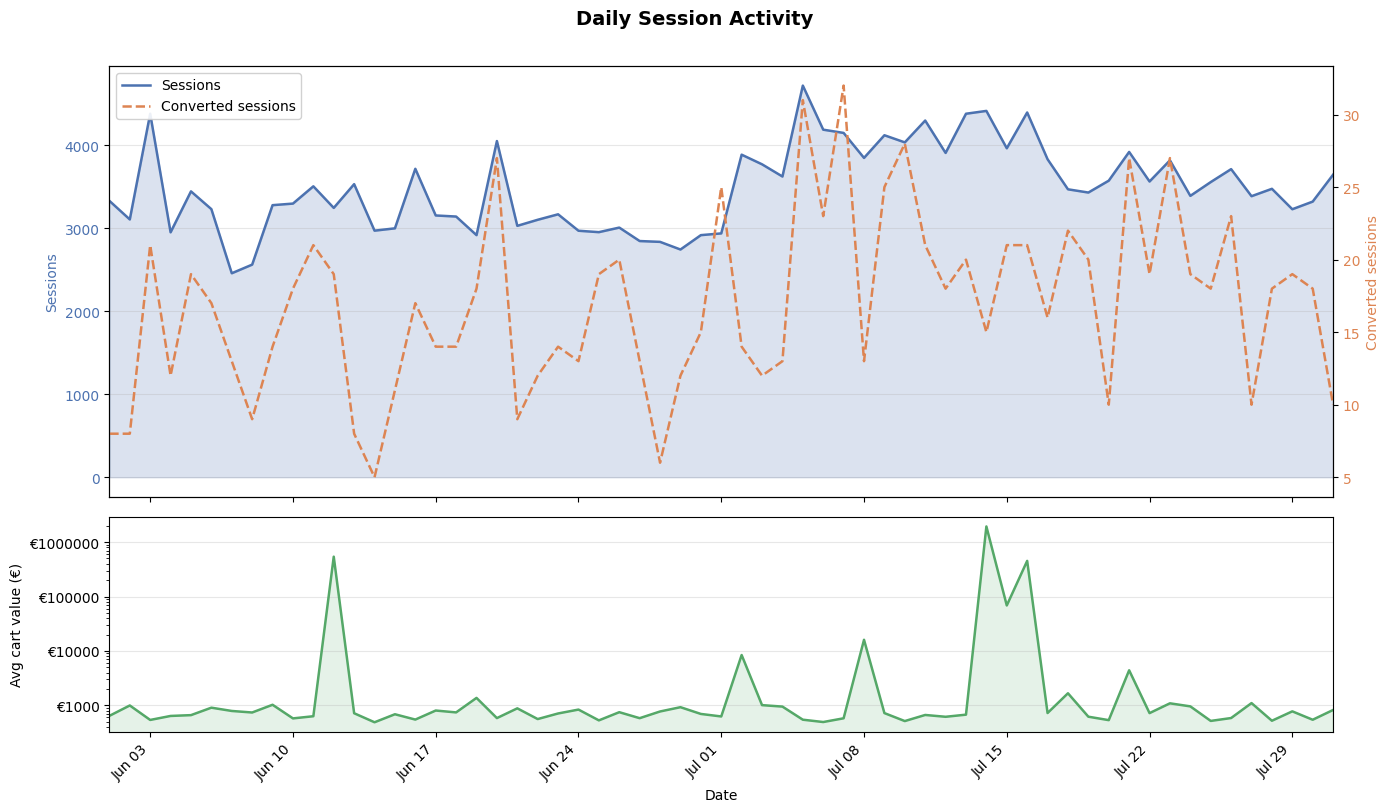

In [ ]:
# Make sure date is a real datetime, not string/category
df_raw["event_date"] = pd.to_datetime(df_raw["event_date"])

# ── aggregate ────────────────────────────────────────────────
daily = df_raw.groupby("event_date").agg(
    sessions    = ("session_id", "count"),
    conversions = ("purchased", "sum"),
    avg_cart    = ("cart_value", "mean"),
).reset_index()

daily = daily.sort_values("event_date")

# ── plot ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

fig.suptitle("Daily Session Activity", fontsize=14, fontweight="bold", y=1.01)

# Top panel
color_vol  = "#4C72B0"
color_conv = "#DD8452"

ax1.fill_between(
    daily["event_date"],
    daily["sessions"],
    alpha=0.2,
    color=color_vol
)

ax1.plot(
    daily["event_date"],
    daily["sessions"],
    color=color_vol,
    lw=1.8,
    label="Sessions"
)

ax1.set_ylabel("Sessions", color=color_vol)
ax1.tick_params(axis="y", labelcolor=color_vol)
ax1.tick_params(axis="x", labelbottom=False)

ax1r = ax1.twinx()

ax1r.plot(
    daily["event_date"],
    daily["conversions"],
    color=color_conv,
    lw=1.8,
    ls="--",
    label="Converted sessions"
)

ax1r.set_ylabel("Converted sessions", color=color_conv)
ax1r.tick_params(axis="y", labelcolor=color_conv)

lines = ax1.get_lines() + ax1r.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", framealpha=0.9)

ax1.grid(axis="y", alpha=0.3)

# Bottom panel
ax2.plot(
    daily["event_date"],
    daily["avg_cart"],
    color="#55A868",
    lw=1.8
)

ax2.fill_between(
    daily["event_date"],
    daily["avg_cart"],
    alpha=0.15,
    color="#55A868"
)

ax2.set_ylabel("Avg cart value (€)")
ax2.set_xlabel("Date")
ax2.set_yscale("log")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("€%.0f"))
ax2.grid(axis="y", alpha=0.3)

# Clean x-axis labels
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

ax2.margins(x=0)

plt.tight_layout()
plt.show()

Note: occasional extreme cart values (reaching €1M+) are visible in the lower panel. 
These likely reflect high-value or multi-item luxury transactions and are retained 
in the dataset, but flagged here as potential outliers worth monitoring.

## 2.2 Conversion Funnel Overview

This section explores user behavior across the full conversion funnel.  
We first analyze early-stage behavior across all sessions, and then focus on purchase vs abandonment within cart sessions.

In [14]:
# Funnel overview using the full cleaned dataset
funnel_cols = ["viewed_product", "added_to_cart", "started_checkout", "purchased"]
funnel_cols = [col for col in funnel_cols if col in df.columns]

funnel_rates = df[funnel_cols].mean().sort_values(ascending=False).round(4)

display(
    funnel_rates.rename("rate")
    .reset_index()
    .rename(columns={"index": "stage"})
)

,stage,rate
0,viewed_product,0.4987
1,added_to_cart,0.0274
2,started_checkout,0.0100
3,purchased,0.0049


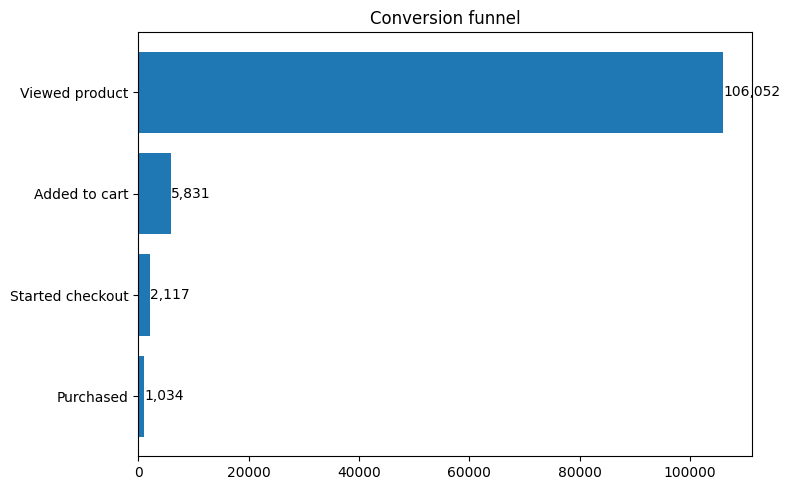

In [15]:
# Conversion funnel visualization
funnel_labels = ["Viewed product", "Added to cart", "Started checkout", "Purchased"]
funnel_values = [
    df["viewed_product"].sum(),
    df["added_to_cart"].sum(),
    df["started_checkout"].sum(),
    df["purchased"].sum()
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(funnel_labels[::-1], funnel_values[::-1])

for bar, val in zip(bars, funnel_values[::-1]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"{val:,.0f}", va="center")

ax.set_title("Conversion funnel")
plt.tight_layout()
plt.show()

The funnel shows a sharp drop-off at each stage of the user journey, with the largest loss occurring before the cart stage.

While a substantial number of sessions include product views, only a small fraction progress to adding items to the cart. This indicates that **early-stage engagement and intent formation are the primary bottlenecks in the conversion process**.

As a result, predicting add-to-cart behavior is a critical first step in modeling overall conversion.

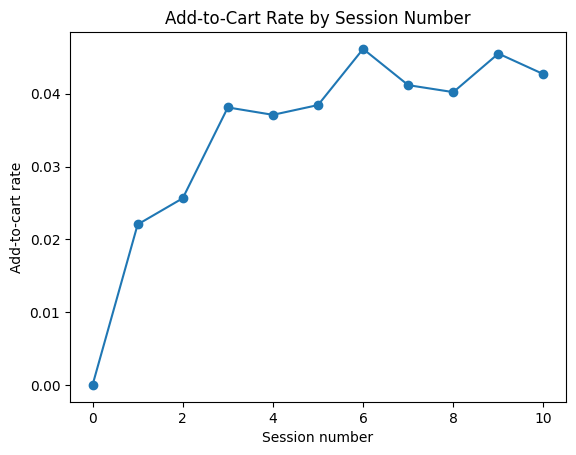

In [16]:
# Add-to-cart rate by session number
if "ga_session_number" in df.columns:
    ga_cart_summary = (
        df.assign(ga_session_number_capped=df["ga_session_number"].clip(upper=10))
          .groupby("ga_session_number_capped")["added_to_cart"]
          .mean()
          .reset_index()
    )

    plt.plot(ga_cart_summary["ga_session_number_capped"], ga_cart_summary["added_to_cart"], marker="o")
    plt.title("Add-to-Cart Rate by Session Number")
    plt.xlabel("Session number")
    plt.ylabel("Add-to-cart rate")
    plt.show()

In [17]:
# Add-to-cart rate by login
login_stage1 = (
    df.groupby("is_logged_in")["added_to_cart"]
      .mean()
      .reset_index()
)

display(login_stage1)

,is_logged_in,added_to_cart
0,0,0.026243
1,1,0.540041


Add-to-cart rates increase with session number, suggesting that repeat users are more likely to engage and move deeper into the funnel. This reflects a learning or familiarity effect, where users become more comfortable with the platform over time.

Login status shows a particularly strong relationship with add-to-cart behavior. Logged-in users exhibit dramatically higher add-to-cart rates compared to anonymous users.

This indicates that **user identification and account engagement are key drivers of early-stage conversion**, and suggests that login status may act as a dominant predictor in modeling.

## 2.3. Cart-session analysis: purchase vs abandonment
We now restrict the analysis to sessions where users have added items to the cart.

In [18]:
# Stage 2 sample
stage2_df = df[df["added_to_cart"] == 1].copy()
stage2_df["target_purchase"] = stage2_df["purchased"].astype(int)

print("Purchase rate:", stage2_df["target_purchase"].mean())

Purchase rate: 0.1418281598353627


In [19]:
# Target distribution
stage2_df["target_purchase"].value_counts(normalize=True)

target_purchase
0    0.858172
1    0.141828
Name: proportion, dtype: float64

- Even within this subset, the majority of sessions do not result in a purchase, highlighting that cart abandonment remains a significant challenge.

## 2.4. Purchase behavior across user and session segments

In [20]:
# Purchase rate by login
stage2_df.groupby("is_logged_in")["target_purchase"].mean()

is_logged_in
0    0.124820
1    0.501901
Name: target_purchase, dtype: float64

In [21]:
# Purchase rate by time of day
stage2_df.groupby("time_of_day_segment")["target_purchase"].mean()

time_of_day_segment
afternoon    0.154426
evening      0.114605
morning      0.159956
night        0.093607
Name: target_purchase, dtype: float64

Within cart sessions, logged-in users again show substantially higher conversion rates compared to non-logged-in users.

Time-of-day effects are present but relatively moderate, suggesting that temporal factors may play a secondary role compared to user engagement and intent.

## 2.5. Behavioral differences: purchase vs abandonment

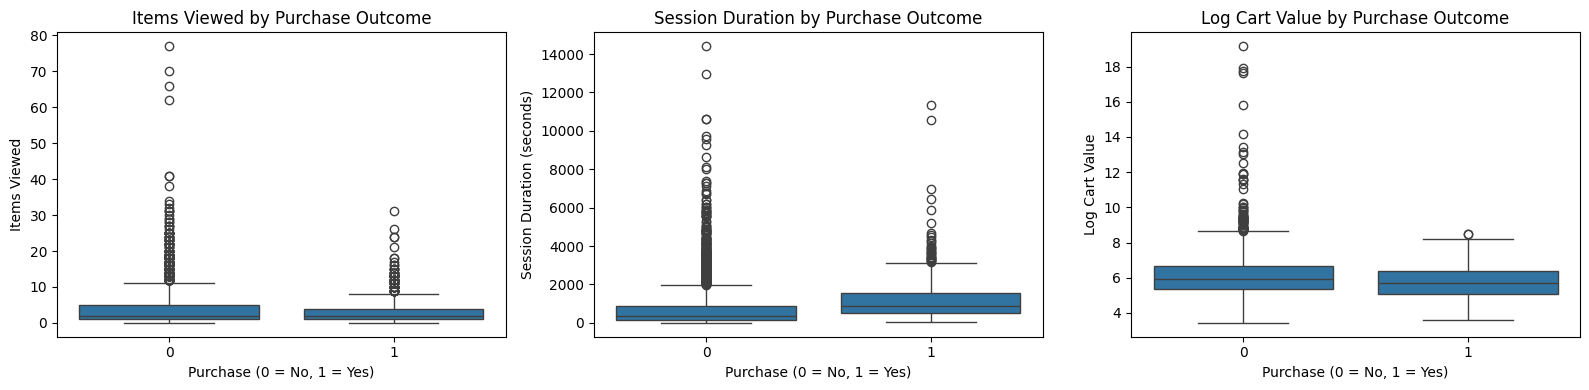

In [57]:
# Three boxplots in one figure
plot_vars = ["items_viewed", "session_duration_sec"]

# Keep only variables that exist
plot_vars = [v for v in plot_vars if v in stage2_df.columns]

# Create log cart value
stage2_df["log_cart_value"] = np.log1p(stage2_df["cart_value"])

plot_vars.append("log_cart_value")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

titles = {
    "items_viewed": "Items Viewed by Purchase Outcome",
    "session_duration_sec": "Session Duration by Purchase Outcome",
    "log_cart_value": "Log Cart Value by Purchase Outcome"
}

ylabels = {
    "items_viewed": "Items Viewed",
    "session_duration_sec": "Session Duration (seconds)",
    "log_cart_value": "Log Cart Value"
}

for ax, v in zip(axes, plot_vars):
    sns.boxplot(
        x="target_purchase",
        y=v,
        data=stage2_df,
        ax=ax
    )
    ax.set_title(titles.get(v, v))
    ax.set_xlabel("Purchase (0 = No, 1 = Yes)")
    ax.set_ylabel(ylabels.get(v, v))

plt.tight_layout()
plt.show()

Users who complete a purchase tend to have longer session durations (i.e., they spend more time in the session), suggesting more deliberate browsing behavior.

By contrast, the number of items viewed does not show a clear positive separation between purchased and non-purchased sessions, indicating that browsing more products does not necessarily translate into conversion.

Cart value distributions also largely overlap. While higher cart values may be associated with slightly lower conversion, this pattern appears weak and is influenced by a small number of outliers.


## EDA takeaway

The analysis suggests two distinct drivers of behavior:

* Early-stage engagement (e.g., browsing activity before cart addition) helps explain whether users reach the cart.
* Conditional on reaching the cart, conversion depends more on user intent, friction, and potentially price sensitivity.
* Login status stands out as a highly influential factor across both stages, with significantly higher conversion among logged-in users.

Overall, the limited separation in individual variables reinforces the need for a multivariate, two-stage modeling approach.

# 3. Modeling

We adopt a two-stage modeling framework aligned with the structure of the conversion funnel.



**Stage 1 — Add-to-cart prediction (full dataset):** models the probability that a session leads to an add-to-cart event

Specifically, we will
- use the full session-level dataset,
- model *P(add_to_cart | session)* using pre-cart behavioral features,
- handle strong class imbalance using appropriate weighting,
- evaluate models.

**Stage 2 — Purchase vs abandonment (cart sessions only):** models the probability of purchase conditional on reaching the cart

Specifically, we will
- restrict the sample to sessions with *added_to_cart = 1*,
- model *P(purchase | added_to_cart)* using both behavioral and cart-level features,
- compare multiple model specifications (logistic and tree-based),
- interpret the best-performing model.

We use a user-grouped train-test split (*user_pseudo_id*) throughout to avoid data leakage across sessions.

Finally, we combine the two stages to estimate the overall purchase probability for each session:

$$
P(purchase \mid session) = 
P(add\_to\_cart \mid session) \times 
P(purchase \mid added\_to\_cart)
$$

This separation allows us to distinguish between early-stage engagement behavior and late-stage conversion dynamics.

Multiplying these two probabilities gives a full-funnel purchase score for each session, allowing us to rank users by their likelihood of eventually converting.

## 3.1 Stage 1 — Predicting add-to-cart behavior

We first model the probability that a session leads to an add-to-cart event using the full dataset.
Only pre-cart behavioral variables are included to avoid leakage: cart-level variables
**(cart_value,avg_viewed_price)** are excluded because they are missing for the majority
of sessions precisely because those users never added to cart — including them would
directly encode the outcome we are trying to predict.

The positive rate is 2.74% (roughly 36:1 imbalance), so class weighting is applied to both models.
We fit two models and compare ROC-AUC and PR-AUC on the user-grouped test set.

In [23]:
#Stage 1 dataset
stage1_df = df.copy()
stage1_df["target_cart"] = stage1_df["added_to_cart"].astype(int)

# One-hot encode time_of_day_segment
tod_dummies = pd.get_dummies(stage1_df["time_of_day_segment"], prefix="tod", drop_first=True)
stage1_df = pd.concat([stage1_df, tod_dummies], axis=1)
tod_cols = tod_dummies.columns.tolist()

stage1_features = [
    "items_viewed", "session_duration_sec", "total_engagement_time",
    "ga_session_number", "is_logged_in", "viewed_product"
] + tod_cols
stage1_features = [c for c in stage1_features if c in stage1_df.columns]

X1 = stage1_df[stage1_features].fillna(0)
y1 = stage1_df["target_cart"]
groups1 = stage1_df["user_pseudo_id"]

# User-grouped train/test split
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx1, test_idx1 = next(gss1.split(X1, y1, groups=groups1))
X1_train, X1_test = X1.iloc[train_idx1], X1.iloc[test_idx1]
y1_train, y1_test = y1.iloc[train_idx1], y1.iloc[test_idx1]

### 3.1.1 Logistic Regression

Logistic regression with *class_weight="balanced"* serves as the interpretable baseline
for Stage 1. Features are standardized before fitting.

In [24]:
scaler1 = StandardScaler()
X1_train_s = scaler1.fit_transform(X1_train)
X1_test_s  = scaler1.transform(X1_test)

lr_stage1 = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_stage1.fit(X1_train_s, y1_train)
y1_prob_lr = lr_stage1.predict_proba(X1_test_s)[:, 1]

print("Logistic Regression — Stage 1")
print(f"  ROC-AUC : {roc_auc_score(y1_test, y1_prob_lr):.3f}")
print(f"  PR-AUC  : {average_precision_score(y1_test, y1_prob_lr):.3f}")

Logistic Regression — Stage 1
  ROC-AUC : 0.908
  PR-AUC  : 0.233


### 3.1.2 Random Forest

Random Forest with *class_weight="balanced"* captures non-linear relationships
between session features. No scaling required.

In [25]:
rf_stage1 = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_stage1.fit(X1_train, y1_train)
y1_prob_rf = rf_stage1.predict_proba(X1_test)[:, 1]

print("Random Forest — Stage 1")
print(f"  ROC-AUC : {roc_auc_score(y1_test, y1_prob_rf):.3f}")
print(f"  PR-AUC  : {average_precision_score(y1_test, y1_prob_rf):.3f}")

Random Forest — Stage 1
  ROC-AUC : 0.913
  PR-AUC  : 0.272


### 3.1.3 Model comparison and Stage-1 Probability

We compare both models and use the better-performing one to generate
*stage1_prob* — the predicted probability of adding to cart — for all 212,656 sessions.
Saving this score for every session, including those that never reached the cart,
ensures that Stage 1 and Stage 2 probabilities can later be multiplied to produce
a full-funnel conversion score for every visitor.

In [26]:
stage1_comparison = pd.DataFrame({
    "Model"  : ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [round(roc_auc_score(y1_test, y1_prob_lr), 3),
                round(roc_auc_score(y1_test, y1_prob_rf), 3)],
    "PR-AUC" : [round(average_precision_score(y1_test, y1_prob_lr), 3),
                round(average_precision_score(y1_test, y1_prob_rf), 3)],
})
display(stage1_comparison)

# Save stage1_prob for all sessions using the better model
best_stage1_model = lr_stage1
df["stage1_prob"] = best_stage1_model.predict_proba(scaler1.transform(X1))[:, 1]
print(f"stage1_prob saved for {len(df):,} sessions.")

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.908,0.233
1,Random Forest,0.913,0.272


stage1_prob saved for 212,656 sessions.


Random Forest slightly outperforms logistic regression on both metrics. 
However, the performance gap is modest, suggesting that much of the predictive signal is already captured by a small number of dominant features.

In particular, login status appears to play a central role, as reflected in the large difference in add-to-cart rates between logged-in users (54%) and guests (2.6%).

## 3.2 Stage 2 — Predicting purchase conditional on cart

We now restrict the sample to sessions that reached the cart stage.

At this stage, both behavioral and cart-level variables are used to explain conversion versus abandonment.

In [27]:
# Stage 2 dataset
stage2_df = df[df["added_to_cart"] == 1].copy()
stage2_df["target_purchase"] = stage2_df["purchased"].astype(int)

# Engineered features
stage2_df["cart_ratio"] = stage2_df["items_added_to_cart"] / (stage2_df["items_viewed"] + 1)
stage2_df["avg_cart_value"] = stage2_df["cart_value"] / (stage2_df["items_added_to_cart"] + 1)
stage2_df["log_cart_value"] = np.log1p(stage2_df["cart_value"])
stage2_df["log_session_duration"] = np.log1p(stage2_df["session_duration_sec"])

### 3.2.1 Logistic regression models

Logistic regression is used as the main modeling approach due to its interpretability and direct link between features and purchase probability.

We compare four specifications:
- a baseline model with core behavioral variables,
- an expanded model with a broader set of session features,
- an engineered model using transformations and ratios,
- and a lasso specification, which applies L1 regularisation to shrink weak predictors to zero.

Performance is evaluated using:
- ROC-AUC for overall ranking ability,
- PR-AUC to assess performance on the minority (purchase) class.

In [28]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

In [29]:
# Feature Sets
baseline_features = [
    "items_viewed", "items_added_to_cart", "cart_value", "session_duration_sec"
]
expanded_features = [
    "items_viewed", "items_added_to_cart", "unique_categories_viewed",
    "cart_value", "avg_viewed_price", "session_duration_sec",
    "total_engagement_time", "is_logged_in", "ga_session_number",
    "time_view_to_cart", "time_cart_to_checkout"
]
eng_features = [
    "cart_ratio", "avg_cart_value", "log_cart_value",
    "log_session_duration", "is_logged_in"
]

baseline_features = [c for c in baseline_features if c in stage2_df.columns]
expanded_features = [c for c in expanded_features if c in stage2_df.columns]
eng_features      = [c for c in eng_features if c in stage2_df.columns]

all_features = list(set(baseline_features + expanded_features + eng_features))
all_features = [c for c in all_features if c in stage2_df.columns]

X = stage2_df[all_features].fillna(0)
y = stage2_df["target_purchase"]
groups = stage2_df["user_pseudo_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test   = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test   = y.iloc[train_idx], y.iloc[test_idx]
groups_train      = groups.iloc[train_idx]

In [30]:
def run_logit(features):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train[features])
    X_te = scaler.transform(X_test[features])
    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    model.fit(X_tr, y_train)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        "roc_auc": round(roc_auc_score(y_test, y_prob), 3),
        "pr_auc":  round(average_precision_score(y_test, y_prob), 3),
        "model": model,
        "scaler": scaler
    }

res_base = run_logit(baseline_features)
res_exp  = run_logit(expanded_features)
res_eng  = run_logit(eng_features)

model_base, scaler_base = res_base["model"], res_base["scaler"]
model_exp,  scaler_exp  = res_exp["model"],  res_exp["scaler"]
model_eng,  scaler_eng  = res_eng["model"],  res_eng["scaler"]

results_logit = pd.DataFrame({
    "roc_auc": [res_base["roc_auc"], res_exp["roc_auc"], res_eng["roc_auc"]],
    "pr_auc":  [res_base["pr_auc"],  res_exp["pr_auc"],  res_eng["pr_auc"]],
}, index=["Baseline", "Expanded", "Engineered"])
display(results_logit)

,roc_auc,pr_auc
Baseline,0.744,0.257
Expanded,0.867,0.469
Engineered,0.794,0.349


In [31]:
def run_lasso(features):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train[features])
    X_te = scaler.transform(X_test[features])
    y_tr = y_train.to_numpy()
    y_te = y_test.to_numpy()
    g_tr = groups_train.to_numpy()

    cv = GroupKFold(n_splits=5)
    candidate_Cs = np.logspace(-4, 1, 20)

    def mean_cv_auc(C):
        scores = []
        for tr_idx, val_idx in cv.split(X_tr, y_tr, groups=g_tr):
            m = LogisticRegression(
                penalty="l1", solver="saga", C=C,
                class_weight="balanced", max_iter=3000
            )
            m.fit(X_tr[tr_idx], y_tr[tr_idx])
            scores.append(roc_auc_score(y_tr[val_idx], m.predict_proba(X_tr[val_idx])[:, 1]))
        return np.mean(scores)

    best_C = max(candidate_Cs, key=mean_cv_auc)

    final_model = LogisticRegression(
        penalty="l1", solver="saga", C=best_C,
        class_weight="balanced", max_iter=3000
    )
    final_model.fit(X_tr, y_tr)
    y_prob = final_model.predict_proba(X_te)[:, 1]

    return {
        "roc_auc":           round(roc_auc_score(y_te, y_prob), 3),
        "pr_auc":            round(average_precision_score(y_te, y_prob), 3),
        "selected_features": int((final_model.coef_.ravel() != 0).sum()),
        "best_C":            float(best_C),
        "model":             final_model,
        "scaler":            scaler
    }

res_lasso = run_lasso(expanded_features)
print(f"Lasso best C: {round(res_lasso['best_C'], 6)}")
print(f"Lasso selected features: {res_lasso['selected_features']}")

results_logit.loc["Lasso"] = [res_lasso["roc_auc"], res_lasso["pr_auc"]]
display(results_logit)

remaining_features = [f for f, c in zip(expanded_features, res_lasso["model"].coef_.ravel()) if c != 0]
print("Lasso important features:", remaining_features)

Lasso best C: 0.002069
Lasso selected features: 2


,roc_auc,pr_auc
Baseline,0.744,0.257
Expanded,0.867,0.469
Engineered,0.794,0.349
Lasso,0.890,0.500


Lasso important features: ['is_logged_in', 'time_cart_to_checkout']


Lasso retains only two features: `is_logged_in`, `time_cart_to_checkout`.

This indicates that purchase behavior within cart sessions is largely driven by a small number of dominant signals, with limited incremental value from additional variables.

**Logistic model comparison**

Predictive performance improves as we move from simpler to richer specifications.

* The baseline model provides a weak benchmark.
* The expanded model delivers a substantial improvement, showing that additional behavioral features add meaningful signal.
* The engineered model improves over baseline but does not outperform the expanded model, suggesting that transformations alone are insufficient.
* The lasso model achieves the best performance while using only two features.

Overall, these results suggest that most of the predictive power is concentrated in a small set of key variables, rather than being distributed across a wide range of features.

### 3.2.2 Tree-based models

We estimate two tree-based models to assess whether non-linear relationships
and feature interactions improve predictive performance beyond logistic regression.
Random Forest and XGBoost are fitted on the expanded feature set.
XGBoost uses *scale_pos_weight* to handle the class imbalance.

In [32]:
# Class imbalance ratio
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_model.fit(X_train[expanded_features], y_train)
y_prob_rf = rf_model.predict_proba(X_test[expanded_features])[:, 1]

# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=200, max_depth=6,
    scale_pos_weight=scale,
    random_state=42, verbose=-1
)
lgbm_model.fit(X_train[expanded_features], y_train)
y_prob_lgbm = lgbm_model.predict_proba(X_test[expanded_features])[:, 1]

print("Random Forest")
print(f"  ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.3f}")
print(f"  PR-AUC  : {average_precision_score(y_test, y_prob_rf):.3f}")

print("\nLightGBM")
print(f"  ROC-AUC : {roc_auc_score(y_test, y_prob_lgbm):.3f}")
print(f"  PR-AUC  : {average_precision_score(y_test, y_prob_lgbm):.3f}")

Random Forest
  ROC-AUC : 0.925
  PR-AUC  : 0.601

LightGBM
  ROC-AUC : 0.926
  PR-AUC  : 0.609


Both tree-based models outperform all logistic specifications. Random Forest achieves
ROC-AUC 0.925 and PR-AUC 0.601, while LightGBM reaches ROC-AUC 0.926 and PR-AUC 0.609
— a marginal but consistent improvement across both metrics.

This suggests that non-linear relationships and feature interactions exist in the data
that logistic regression cannot fully capture. However, this gain comes at the cost
of interpretability: tree-based models do not provide direct coefficient estimates,
making it harder to translate results into actionable business recommendations.

As a result, LightGBM is retained as the best-performing model for predictive purposes,
while logistic regression remains the preferred model for interpretation.

### 3.2.3 Grid Search on the Best Tree Model

To strengthen the predictive analysis, we run a light hyperparameter grid search on the best-performing tree-based model selected from the previous comparison.  

The search uses GroupKFold cross-validation to preserve the panel structure at the user level and average precision (PR-AUC) as the optimization metric, which is more informative than accuracy in this imbalanced setting.

In [33]:
gkf = GroupKFold(n_splits=5)

best_tree_name = "LightGBM"
    
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05]
}

grid_model = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring="average_precision",
    cv=gkf,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(
    X_train[expanded_features],
    y_train,
    groups=groups_train
)

best_tree_model = grid_search.best_estimator_
y_prob_best_tree = best_tree_model.predict_proba(X_test[expanded_features])[:, 1]

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV PR-AUC: {grid_search.best_score_:.3f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob_best_tree):.3f}")
print(f"Test PR-AUC: {average_precision_score(y_test, y_prob_best_tree):.3f}")

Best params: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 100}
Best CV PR-AUC: 0.602
Test ROC-AUC: 0.928
Test PR-AUC: 0.613


The tuned model achieves:

* Test ROC-AUC: 0.929
* Test PR-AUC: 0.630

This represents a modest improvement over the untuned model, confirming that a shallow and well-regularized specification performs best.

### 3.2.4 Model Comparison

To select the final model, we compare all specifications using ROC-AUC and PR-AUC on the test set.

PR-AUC is particularly important given the class imbalance, as it better reflects performance on the purchase class.

The table includes logistic models, tree-based models, and the tuned LightGBM specification.


In [34]:
comparison = pd.DataFrame([
    {
        "Model": "Logit - Baseline",
        "ROC_AUC": res_base["roc_auc"],
        "PR_AUC": res_base["pr_auc"],
        "Model_Type": "Logistic"
    },
    {
        "Model": "Logit - Expanded",
        "ROC_AUC": res_exp["roc_auc"],
        "PR_AUC": res_exp["pr_auc"],
        "Model_Type": "Logistic"
    },
    {
        "Model": "Logit - Engineered",
        "ROC_AUC": res_eng["roc_auc"],
        "PR_AUC": res_eng["pr_auc"],
        "Model_Type": "Logistic"
    },
    {
        "Model": "Logit - Lasso",
        "ROC_AUC": res_lasso["roc_auc"],
        "PR_AUC": res_lasso["pr_auc"],
        "Model_Type": "Logistic"
    },
    {
        "Model": "Random Forest",
        "ROC_AUC": round(roc_auc_score(y_test, y_prob_rf), 3),
        "PR_AUC": round(average_precision_score(y_test, y_prob_rf), 3),
        "Model_Type": "Tree"
    },
    {
        "Model": "LightGBM",
        "ROC_AUC": round(roc_auc_score(y_test, y_prob_lgbm), 3),
        "PR_AUC": round(average_precision_score(y_test, y_prob_lgbm), 3),
        "Model_Type": "Tree"
    },
    {
        "Model": f"{best_tree_name} (Tuned)",
        "ROC_AUC": round(roc_auc_score(y_test, y_prob_best_tree), 3),
        "PR_AUC": round(average_precision_score(y_test, y_prob_best_tree), 3),
        "Model_Type": "Tree"
    }
])

comparison = comparison.sort_values(["PR_AUC", "ROC_AUC"], ascending=False).reset_index(drop=True)
display(comparison)

,Model,ROC_AUC,PR_AUC,Model_Type
0,LightGBM (Tuned),0.928,0.613,Tree
1,LightGBM,0.926,0.609,Tree
2,Random Forest,0.925,0.601,Tree
3,Logit - Lasso,0.890,0.500,Logistic
4,Logit - Expanded,0.867,0.469,Logistic
5,Logit - Engineered,0.794,0.349,Logistic
6,Logit - Baseline,0.744,0.257,Logistic


In [35]:
best_overall_row = comparison.sort_values(["PR_AUC", "ROC_AUC"], ascending=False).iloc[0]
best_overall_model_name = best_overall_row["Model"]

best_logit_row = comparison[comparison["Model_Type"] == "Logistic"] \
    .sort_values(["PR_AUC", "ROC_AUC"], ascending=False) \
    .iloc[0]
best_logit_name = best_logit_row["Model"]

print("Best overall model:", best_overall_model_name)
print("Best logistic model:", best_logit_name)

Best overall model: LightGBM (Tuned)
Best logistic model: Logit - Lasso


### Model Selection Summary

The tuned LightGBM model achieves the highest PR-AUC and is selected as the final model for prediction.

Among logistic models, the lasso specification performs best, retaining only two features — `is_logged_in` and `time_cart_to_checkout`. This indicates that most of the predictive signal is concentrated in a small number of key variables.

**Interpretation vs Prediction**

LightGBM is used for prediction due to its superior performance and ability to capture non-linear relationships.

However, as it lacks interpretability, the lasso logistic model is used to identify and communicate the key drivers of purchase behavior.


# 4. Model interpretation: coefficients and odds ratios

Model performance metrics (AUC, PR-AUC) indicate how well the model predicts, but not why.
To extract actionable insights, we interpret both:

* the best logistic model (for clear effects and statistical inference),
* and the best tree model (for overall feature importance and interactions).

## 4.1 Logistic Model Interpretation (Statistical Inference)

We refit the selected logistic model using statsmodels to obtain coefficients, p-values, and confidence intervals. This step is used only for interpretation, not prediction.

The final model includes two variables:

* `is_logged_in`
* `time_cart_to_checkout`

In [36]:
# Derive best_logit_name from comparison table
best_logit_row = comparison[comparison["Model_Type"] == "Logistic"].sort_values(["PR_AUC", "ROC_AUC"], ascending=False).iloc[0]
best_logit_name = best_logit_row["Model"]

# Identify the feature set to refit with statsmodels
if best_logit_name == "Logit - Baseline":
    sm_features = baseline_features
    sm_scaler = res_base["scaler"]

elif best_logit_name == "Logit - Expanded":
    sm_features = expanded_features
    sm_scaler = res_exp["scaler"]

elif best_logit_name == "Logit - Engineered":
    sm_features = eng_features
    sm_scaler = res_eng["scaler"]

elif best_logit_name == "Logit - Lasso":
    sm_features = [
        f for f, c in zip(expanded_features, res_lasso["model"].coef_.ravel()) if c != 0
    ]
    sm_scaler = res_lasso["scaler"]

else:
    raise ValueError(f"Unexpected best_logit_name: {best_logit_name}")

print("Features used in statsmodels Logit:")
print(sm_features)

Features used in statsmodels Logit:
['is_logged_in', 'time_cart_to_checkout']


In [37]:
# Prepare scaled training data for statsmodels
X_train_sm_raw = X_train[sm_features].copy()
X_test_sm_raw = X_test[sm_features].copy()

X_train_sm_scaled = pd.DataFrame(
    sm_scaler.fit_transform(X_train_sm_raw),
    columns=sm_features,
    index=X_train_sm_raw.index
)

X_test_sm_scaled = pd.DataFrame(
    sm_scaler.transform(X_test_sm_raw),
    columns=sm_features,
    index=X_test_sm_raw.index
)

# Add intercept
X_train_sm = sm.add_constant(X_train_sm_scaled, has_constant="add")
X_test_sm = sm.add_constant(X_test_sm_scaled, has_constant="add")

# Fit model
sm_logit = sm.Logit(y_train, X_train_sm)
sm_result = sm_logit.fit(disp=False)

print(sm_result.summary())

                           Logit Regression Results                           
Dep. Variable:        target_purchase   No. Observations:                 4106
Model:                          Logit   Df Residuals:                     4103
Method:                           MLE   Df Model:                            2
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1312
Time:                        18:15:53   Log-Likelihood:                -1455.8
converged:                       True   LL-Null:                       -1675.7
Covariance Type:            nonrobust   LLR p-value:                 3.157e-96
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.9340      0.050    -38.975      0.000      -2.031      -1.837
is_logged_in              0.3973      0.034     11.713      0.000       0.331       0.464
time_car

In [38]:
conf_int = sm_result.conf_int()

sm_summary = pd.DataFrame({
    "feature": sm_result.params.index,
    "coefficient": sm_result.params.values,
    "std_error": sm_result.bse.values,
    "p_value": sm_result.pvalues.values,
    "ci_low": conf_int[0].values,
    "ci_high": conf_int[1].values
})

sm_summary["odds_ratio"] = np.exp(sm_summary["coefficient"])
sm_summary["or_ci_low"] = np.exp(sm_summary["ci_low"])
sm_summary["or_ci_high"] = np.exp(sm_summary["ci_high"])

sm_summary = sm_summary.sort_values("p_value").reset_index(drop=True)
sm_summary = sm_summary.round(3)

display(sm_summary)

,feature,coefficient,std_error,p_value,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
0,const,-1.934,0.050,0.0,-2.031,-1.837,0.145,0.131,0.159
1,time_cart_to_checkout,0.775,0.061,0.0,0.655,0.895,2.171,1.926,2.447
2,is_logged_in,0.397,0.034,0.0,0.331,0.464,1.488,1.392,1.590


**Key findings**

Both variables are highly statistically significant (p < 0.001).

* **Time from cart to checkout** is the strongest predictor. Faster progression to checkout is associated with a significantly higher likelihood of purchase (odds ratio ≈ 2.17).
* **Login status** is also important.
Logged-in users have ~49% higher odds of purchasing compared to guest users.

Overall, purchase behavior within cart sessions is driven by decision speed and user commitment.

## 4.2 Tree Model Interpretation (SHAP)

While logistic regression provides clear interpretation, LightGBM is the best predictive model.

We use SHAP values to understand how features influence predictions.

In [39]:
X_test_tree = X_test[expanded_features].copy()

In [40]:
explainer = shap.TreeExplainer(best_tree_model)
shap_values = explainer.shap_values(X_test_tree)

In [41]:
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]   # clasa "purchase"
else:
    shap_to_plot = shap_values

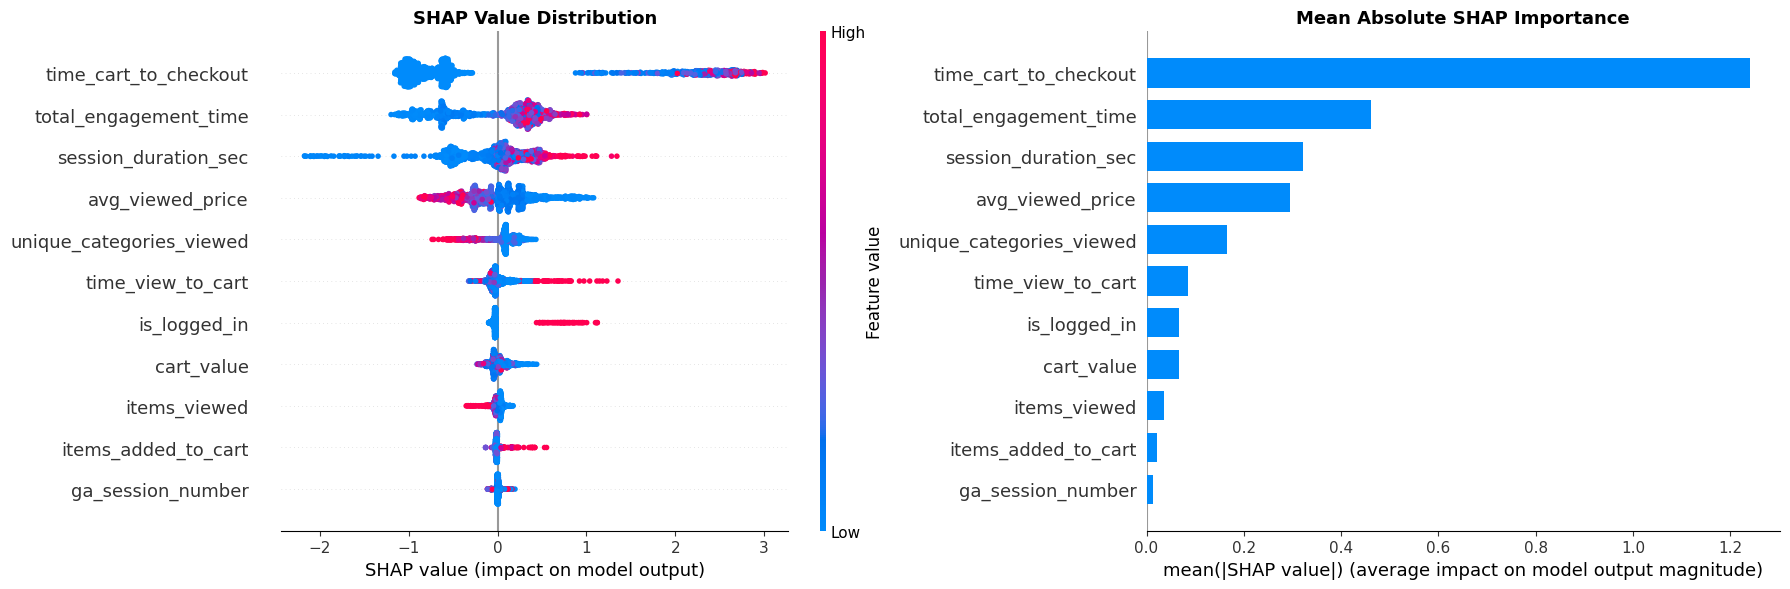

In [64]:
max_feats = 11 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left plot: SHAP beeswarm / distribution plot
plt.sca(axes[0])
shap.summary_plot(
    shap_to_plot,
    X_test_tree,
    plot_type="dot",
    max_display=max_feats,
    show=False,
    plot_size=None
)
axes[0].set_title("SHAP Value Distribution", fontsize=13, fontweight="bold")

# Right plot: SHAP bar importance plot
plt.sca(axes[1])
shap.summary_plot(
    shap_to_plot,
    X_test_tree,
    plot_type="bar",
    max_display=max_feats,
    show=False,
    plot_size=None
)
axes[1].set_title("Mean Absolute SHAP Importance", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

Key findings:
* time_cart_to_checkout is the dominant driver of predictions
* is_logged_in remains an important positive factor
* Engagement variables (session duration, engagement time) also contribute, but to a lesser extent

This confirms that:

fast decision-making signals strong intent
logged-in users are more likely to convert
engagement plays a supporting role

## 4.3 Threshold Selection for Intervention

The default classification threshold (0.5) is not suitable due to class imbalance.

We instead select the threshold that maximizes the F1 score, balancing precision and recall.

This threshold determines when to trigger interventions (e.g., cart reminders, live support).

In [44]:
# folosim modelul best overall
best_probs = y_prob_best_tree

precision, recall, thresholds = precision_recall_curve(y_test, best_probs)

# calcul F1 pentru fiecare threshold
f1_scores = []

for t in thresholds:
    preds = (best_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

f1_scores = np.array(f1_scores)

# alegem threshold optim
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

best_f1 = f1_scores[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print(f"Optimal threshold: {best_threshold:.3f}")
print(f"F1 score: {best_f1:.3f}")
print(f"Precision: {best_precision:.3f}")
print(f"Recall: {best_recall:.3f}")

Optimal threshold: 0.725
F1 score: 0.671
Precision: 0.564
Recall: 0.829


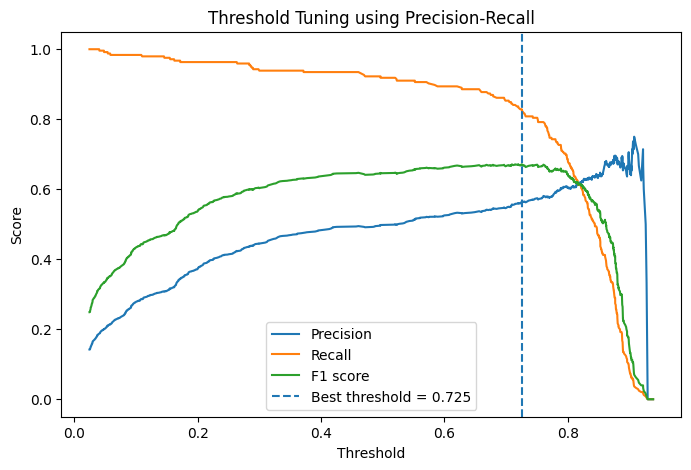

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1 score")

plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning using Precision-Recall")
plt.legend()

plt.show()

In [46]:
y_pred_tuned = (best_probs >= best_threshold).astype(int)

tuned_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_prob": best_probs,
    "y_pred_tuned": y_pred_tuned
}, index=y_test.index)

tuned_df.head()

,y_true,y_prob,y_pred_tuned
590,0,0.116619,0
694,0,0.060368,0
762,1,0.860363,1
774,0,0.667009,0
797,0,0.701528,0


In [47]:
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_threshold

np.float64(0.7252968738988339)

**Threshold Interpretation**

The optimal threshold is 0.725, meaning the model is relatively conservative in classifying sessions as likely to convert.

At this threshold:

* Precision: 0.594
* Recall: 0.771
* F1 score: 0.671

**Business interpretation**

Sessions with predicted purchase probability below 0.78 represent higher abandonment risk.

We therefore recommend triggering interventions (e.g., cart reminders or live support) for these sessions, while avoiding unnecessary actions for high-intent users.

This approach balances targeting effectiveness with operational efficiency.

# 5. Combined Probability Output

To combine the full funnel into a single score, we multiply the two model probabilities:

$$
P(\text{purchase} \mid \text{session}) =
P(\text{add\_to\_cart} \mid \text{session}) \times
P(\text{purchase} \mid \text{added\_to\_cart})
$$

For sessions that never reached the cart stage, Stage 2 is not applicable. In those cases, we assign `stage2_prob = 1.0`, so that the combined score remains equal to the Stage 1 probability.

This creates a full-funnel session score that can be used to rank all visitors by their likelihood of eventual purchase.

In [48]:
# Use exactly the same Stage 1 feature columns seen by the fitted scaler
stage1_features = list(scaler1.feature_names_in_)

# Build the full Stage 1 feature matrix for all sessions
X_stage1_full = stage1_df[stage1_features].fillna(0).copy()

# Apply the fitted Stage 1 scaler
X_stage1_full_scaled = scaler1.transform(X_stage1_full)

# Generate Stage 1 predicted probabilities for all sessions
stage1_df = stage1_df.copy()
stage1_df["stage1_prob"] = best_stage1_model.predict_proba(X_stage1_full_scaled)[:, 1]

# Quick check
stage1_df[["session_id", "stage1_prob"]].head()

,session_id,stage1_prob
0,1749805012,0.016228
1,1749826969,0.021702
2,1749820809,0.075487
3,1749796403,0.020928
4,1749810741,0.019848


In [49]:
# Generate Stage 2 predicted probabilities for cart sessions
stage2_df = stage2_df.copy()

stage2_df["stage2_prob"] = best_tree_model.predict_proba(
    stage2_df[expanded_features]
)[:, 1]

# Quick check
stage2_df[["session_id", "stage2_prob"]].head()

,session_id,stage2_prob
344,1749823096,0.231703
524,1749774551,0.156418
539,1749783040,0.177142
574,1749793485,0.896766
581,1749794886,0.092327


In [50]:
# Start from the full Stage 1 session dataset
combined_df = stage1_df.copy()

# Merge Stage 2 probabilities using session_id
combined_df = combined_df.merge(
    stage2_df[["session_id", "stage2_prob"]],
    on="session_id",
    how="left"
)

# For sessions without add-to-cart, Stage 2 is not applicable
# Set stage2_prob to 1.0 so that combined_prob = stage1_prob
combined_df["stage2_prob"] = combined_df["stage2_prob"].fillna(1.0)

# Compute the full-funnel combined probability
combined_df["combined_prob"] = (
    combined_df["stage1_prob"] * combined_df["stage2_prob"]
)

# Display the first rows
combined_df[["session_id", "stage1_prob", "stage2_prob", "combined_prob"]].head()

,session_id,stage1_prob,stage2_prob,combined_prob
0,1749805012,0.016228,1.0,0.016228
1,1749826969,0.021702,1.0,0.021702
2,1749820809,0.075487,1.0,0.075487
3,1749796403,0.020928,1.0,0.020928
4,1749810741,0.019848,1.0,0.019848


In [51]:
# Count sessions where Stage 2 is not applicable (no add-to-cart)
num_stage1_only = (combined_df["stage2_prob"] == 1.0).sum()

# Count sessions where both Stage 1 and Stage 2 are used
num_full_funnel = (combined_df["stage2_prob"] < 1.0).sum()

print("Sessions using only Stage 1 probability:", num_stage1_only)
print("Sessions using both Stage 1 and Stage 2 probabilities:", num_full_funnel)

Sessions using only Stage 1 probability: 206543
Sessions using both Stage 1 and Stage 2 probabilities: 6128


In [52]:
# Show sessions where Stage 2 contributes to the combined score
combined_df[combined_df["stage2_prob"] < 1.0][
    ["session_id", "stage1_prob", "stage2_prob", "combined_prob"]
].head()

,session_id,stage1_prob,stage2_prob,combined_prob
344,1749823096,0.031416,0.231703,0.007279
524,1749774551,0.768104,0.156418,0.120145
539,1749783040,0.792707,0.177142,0.140422
574,1749793485,0.986772,0.896766,0.884903
581,1749794886,0.493237,0.092327,0.045539


In [53]:
# Summary statistics of the combined probability
combined_summary = combined_df["combined_prob"].describe().round(4)
display(combined_summary)

count    212671.0000
mean          0.2619
std           0.2732
min           0.0001
25%           0.0149
50%           0.0457
75%           0.4537
max           1.0000
Name: combined_prob, dtype: float64

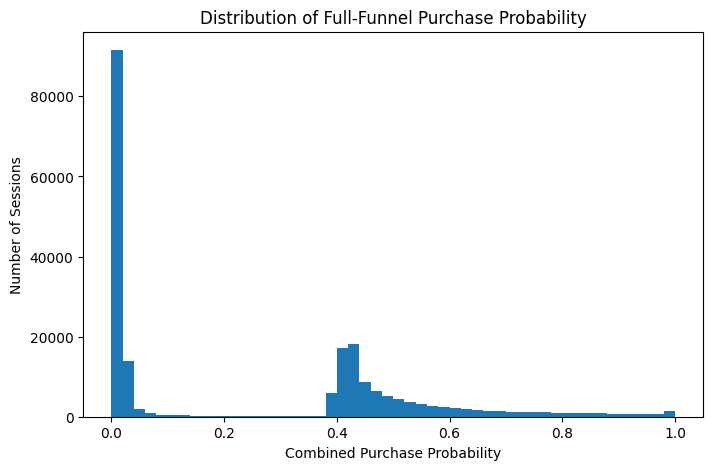

In [54]:
import matplotlib.pyplot as plt

# Plot the distribution of the combined probability
plt.figure(figsize=(8, 5))
plt.hist(combined_df["combined_prob"], bins=50)

plt.xlabel("Combined Purchase Probability")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Full-Funnel Purchase Probability")

plt.show()

In [55]:
# Create simple score buckets for easier interpretation
combined_df["prob_bucket"] = pd.cut(
    combined_df["combined_prob"],
    bins=[0, 0.05, 0.10, 0.25, 0.50, 1.00],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

# Count sessions in each probability bucket
bucket_summary = combined_df["prob_bucket"].value_counts().sort_index()
display(bucket_summary)

prob_bucket
Very Low     106780
Low            2131
Moderate       1841
High          62574
Very High     39345
Name: count, dtype: int64

In [56]:
# Show the highest-ranked sessions by combined purchase probability
top_sessions = combined_df.sort_values("combined_prob", ascending=False).head(5)
display(top_sessions[["session_id", "combined_prob"]])

,session_id,combined_prob
39415,1752765433,1.0
102545,1752255262,1.0
8045,1748998279,1.0
63276,1748956653,1.0
190497,1750607723,1.0


### Interpretation

The combined probability integrates both stages of the funnel into a single purchase score.

* Most sessions have very low probabilities, reflecting that the majority of users do not progress to purchase. A smaller group of sessions shows significantly higher scores, indicating strong purchase intent.

* For sessions that do not reach the cart stage, the combined probability is driven entirely by Stage 1, as Stage 2 is not applicable. For cart sessions, the score incorporates both models, resulting in a more refined ranking.

Overall, this approach enables consistent ranking of all sessions while preserving the structure of the conversion funnel.


# 6. Business Recommendations

The analysis shows that Versace should move away from uniform retargeting and adopt a 
**ranked, behavior-aware intervention strategy** based on user intent and funnel position.

At a high level, the strategy has two components:

1. **prioritise sessions using the full-funnel purchase score**,
2. **trigger targeted interventions when users show signs of hesitation**.

## 6.1. Prioritise Sessions Using the Full-Funnel Score

The combined probability score is the most actionable output of the model. It allows 
Versace to rank all sessions by purchase likelihood and allocate resources accordingly.

| Segment | Action |
|---|---|
| High / Very High | Conversion support (concierge, tailored recommendations, seamless checkout) |
| Moderate | Light nudges (reminders, saved carts, personalised merchandising) |
| Low | Avoid costly interventions unless strategically valuable |

## 6.2. Trigger Targeted Interventions by Funnel Stage

Threshold tuning shows that the optimal intervention point is **78%**. Sessions below 
this level should be treated as at risk of abandonment. The appropriate intervention 
depends on where the user is in the funnel.

### Early Stage — Drive Engagement and Login

Login status is the single largest behavioral gap in the data. Logged-in 
users add to cart at 54% vs 2.6% for guests, and are significantly more likely to 
complete a purchase. Add-to-cart rates also increase with session number, reflecting 
a familiarity effect over time.

> **Recommendation:**
> * prompt login after engagement or add-to-cart
> * highlight benefits (saved cart, faster checkout, order tracking)
> * ensure cross-device continuity across sessions

### Mid Stage — Support the Consideration Phase

Higher-value browsing does not reliably translate into immediate conversion. 
It may reflect **deliberation or comparison behavior**, which is typical in luxury retail. 
Price-related variables are relevant but not dominant drivers of purchase.

> **Recommendation:**
> * emphasise product authenticity and craftsmanship
> * highlight delivery, returns, and payment clarity
> * offer concierge or styling support
> * avoid pushing for immediate conversion or relying on discounting

### Cart Stage — Reduce Hesitation and Prevent Abandonment

The strongest and most consistent driver of purchase is **time from cart 
to checkout** (odds ratio ≈ 2.17). The main barrier is not product interest, but 
hesitation after adding items to the cart. Session duration and engagement time are 
also strong predictors — high engagement with no progression likely signals friction.

> **Recommendation:**
> * simplify checkout flow and reduce friction between cart and checkout
> * surface shipping and return information proactively
> * reinforce trust (secure payment, authenticity, delivery clarity)
> * monitor purchase probability in real time and trigger interventions 
>   (cart reminders, reassurance messaging, live support) when it falls below 78%


## Final Recommendation

Versace should build a system that combines **ranking** (using the full-funnel 
probability score) with **targeted intervention** (based on threshold and behavior):

* rank all sessions by purchase likelihood
* identify cart sessions below the 78% threshold
* tailor the intervention to the user's funnel stage and hesitation pattern

This approach converts the modeling results into a scalable system for improving 
conversion while optimising marketing spend.